### Import

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt

### Load the image

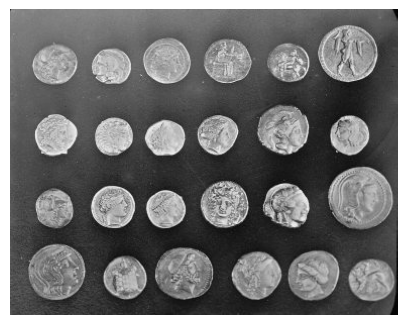

In [8]:
img = cv.imread("output/coins.png")
gray_img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(gray_img, cmap="gray")
plt.axis("off")
plt.show()


### Threshold

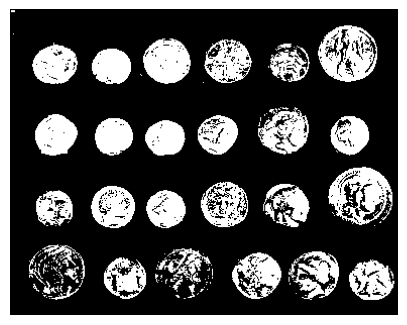

In [9]:
_, binary = cv.threshold(gray_img, 140, 225, cv.THRESH_BINARY)

plt.figure(figsize=(5,5))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()

### Morphological Closing

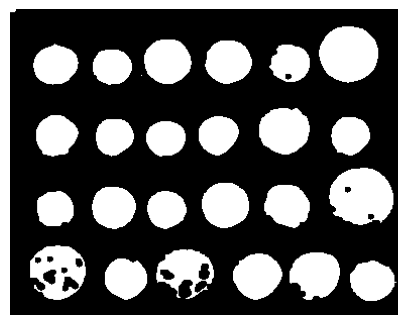

In [10]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (6, 6))
closed = cv.morphologyEx(binary, cv.MORPH_CLOSE, kernel)

plt.figure(figsize=(5,5))
plt.imshow(closed, cmap="gray")
plt.axis("off")
plt.show()

### Finding Contours

In [11]:
contours, _ = cv.findContours(
    closed,
    cv.RETR_EXTERNAL,
    cv.CHAIN_APPROX_SIMPLE
)

filtered = [c for c in contours if cv.contourArea(c) > 50]
no_coins = len(filtered)

print(f"No. of Coines: {no_coins}")

if no_coins>25 or no_coins<22:
    raise ValueError(" Number of Coins is not 24 ± 2.")


No. of Coines: 24


### Draw contours on the original image

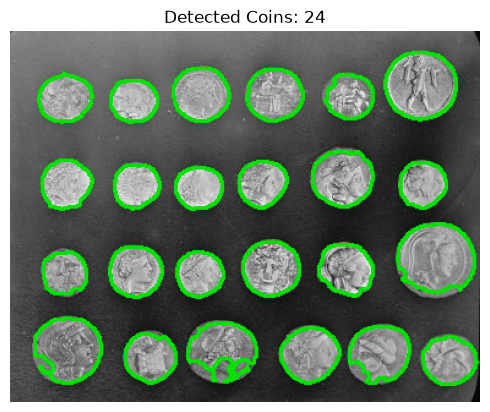

In [12]:
output = img.copy()

for contour in filtered:
    cv.drawContours(output, [contour], -1, (0, 225, 0), 2)

# Display and save
plt.figure(figsize=(5,5))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title(f"Detected Coins: {len(filtered)}")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/6_contours.png", dpi=300)
plt.show()